# Phase 4: Evaluation

**Goal:** Compare T-Learner and X-Learner using proper uplift evaluation metrics.

Standard AUC cannot be used here because there is no per-user ground truth label for uplift. Each user is observed in only one state (treated or control), never both. Instead we use two uplift-specific approaches:

- **Qini curve / Qini AUC:** ranks users by predicted uplift score and measures how much of the total observed uplift is captured by targeting the top-ranked users. A model that perfectly ranks persuadables first captures all the uplift early. The Qini AUC is the area between the model curve and a random targeting baseline.
- **Uplift by decile:** splits users into 10 buckets by predicted uplift score and computes the actual observed visit lift per bucket. A good model should show clearly higher lift in the top deciles and lower or near-zero lift in the bottom deciles.

**Inputs:**
- `data/tlearner_scores.parquet`
- `data/xlearner_scores.parquet`

**Outputs:**
- `images/qini_curve.png`
- `images/uplift_by_decile.png`

## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklift.metrics import qini_auc_score, qini_curve

%matplotlib inline
sns.set_theme(style="whitegrid", palette="muted")
pd.set_option("display.max_columns", None)

## 2. Load Scores

Both score files share the same format: `uplift`, `y_true`, `treatment`. They cover the exact same 279K test users from the same `random_state=1` split, so the comparison is apples-to-apples.

In [2]:
df_t = pd.read_parquet("../data/tlearner_scores.parquet")
df_x = pd.read_parquet("../data/xlearner_scores.parquet")

print("T-Learner scores:", df_t.shape)
print("X-Learner scores:", df_x.shape)
df_t.head()

T-Learner scores: (279592, 3)
X-Learner scores: (279592, 3)


,uplift,y_true,treatment
0,-0.010524,0,0
1,-0.000288,0,0
2,-0.020646,0,1
3,0.013442,0,1
4,0.141881,0,1


## 3. Qini Curve

The Qini curve plots cumulative incremental visit uplift as we target an increasing fraction of users, ordered by predicted uplift score from highest to lowest. The diagonal represents random targeting (no model). A model that correctly identifies persuadables will curve above the diagonal, capturing more uplift with fewer users targeted. Both models are plotted on the same chart for direct comparison.

At each step along the x-axis, the y value is computed as:

```
incremental_visits = visits_in_treatment_so_far - visits_in_control_so_far × (n_treatment_total / n_control_total)
```

The ratio adjustment accounts for the 85/15 treatment/control imbalance. Without it, y would grow faster simply because there are far more treated users than control users.

At x = 1.0 (all users targeted), y reaches the total incremental visits in the test set (~2,458), which is approximately ATE × n_treatment ≈ 0.0103 × 237,653. This is a real count of people: the number of additional visits generated by the ad across the entire test set.

/Users/nicoleshen/Documents/projects/uplift-modeling/venv_uplift/lib/python3.11/site-packages/sklearn/utils/deprecation.py:94: FutureWarning: Function stable_cumsum is deprecated; `sklearn.utils.extmath.stable_cumsum` is deprecated in version 1.8 and will be removed in 1.10. Use `np.cumulative_sum` with the desired dtype directly instead.
  warnings.warn(msg, category=FutureWarning)
/Users/nicoleshen/Documents/projects/uplift-modeling/venv_uplift/lib/python3.11/site-packages/sklearn/utils/deprecation.py:94: FutureWarning: Function stable_cumsum is deprecated; `sklearn.utils.extmath.stable_cumsum` is deprecated in version 1.8 and will be removed in 1.10. Use `np.cumulative_sum` with the desired dtype directly instead.
  warnings.warn(msg, category=FutureWarning)


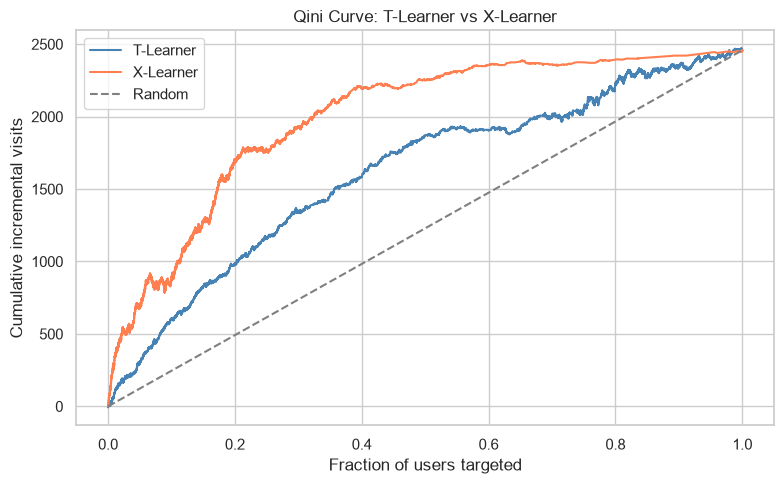

In [3]:
x_t, y_t = qini_curve(df_t["y_true"], df_t["uplift"], df_t["treatment"])
x_x, y_x = qini_curve(df_x["y_true"], df_x["uplift"], df_x["treatment"])

# normalize x to fraction of users targeted (0 to 1)
x_t_norm = x_t / x_t.max()
x_x_norm = x_x / x_x.max()

plt.figure(figsize=(8, 5))
plt.plot(x_t_norm, y_t, color="steelblue", label="T-Learner")
plt.plot(x_x_norm, y_x, color="coral", label="X-Learner")
plt.plot([0, 1], [0, y_t[-1]], color="gray", linestyle="--", label="Random")
plt.xlabel("Fraction of users targeted")
plt.ylabel("Cumulative incremental visits")
plt.title("Qini Curve: T-Learner vs X-Learner")
plt.legend()
plt.tight_layout()
plt.savefig("../images/qini_curve.png", dpi=150, bbox_inches="tight")
plt.show()

In [4]:
checkpoints = [0.2, 0.4, 0.6, 0.8, 1.0]
rows = []
for cp in checkpoints:
    idx_t = np.searchsorted(x_t_norm, cp)
    idx_x = np.searchsorted(x_x_norm, cp)
    y_t_val = round(y_t[min(idx_t, len(y_t) - 1)])
    y_x_val = round(y_x[min(idx_x, len(y_x) - 1)])
    rows.append({
        "Fraction targeted": f"{cp:.0%}",
        "T-Learner incremental visits": y_t_val,
        "X-Learner incremental visits": y_x_val,
        "X-Learner advantage": f"{(y_x_val - y_t_val) / y_t_val * 100:.0f}%",
    })

pd.DataFrame(rows)

,Fraction targeted,T-Learner incremental visits,X-Learner incremental visits,X-Learner advantage
0,20%,984,1684,71%
1,40%,1583,2190,38%
2,60%,1908,2355,23%
3,80%,2227,2394,7%
4,100%,2458,2458,0%


Both models beat random targeting, confirming real signal in both learners. X-Learner stays clearly above T-Learner across the full curve.

The X-Learner advantage is front-loaded: 71% more incremental visits at the top 20% (1,684 vs 984), shrinking to 7% at 80%. In a budget-constrained campaign, targeting only the top users, X-Learner delivers meaningfully more value.

Both curves flatten after 60%. The bottom 40% of users add only 550 more visits between them, consistent with near-zero treatment effect for the majority of the population. At 100% targeting, both models converge to 2,458 incremental visits.

## 4. Qini AUC Score

The Qini AUC is the area between the model's Qini curve and the random baseline. A higher score means the model does a better job of ranking users by true uplift. A score of 0 means the model is no better than random.

In [5]:
auc_t = qini_auc_score(df_t["y_true"], df_t["uplift"], df_t["treatment"])
auc_x = qini_auc_score(df_x["y_true"], df_x["uplift"], df_x["treatment"])

print(f"T-Learner Qini AUC: {auc_t:.4f}")
print(f"X-Learner Qini AUC: {auc_x:.4f}")
print(f"Improvement:        {(auc_x - auc_t) / auc_t * 100:.1f}%")

T-Learner Qini AUC: 0.0380
X-Learner Qini AUC: 0.0760
Improvement:        99.9%


/Users/nicoleshen/Documents/projects/uplift-modeling/venv_uplift/lib/python3.11/site-packages/sklearn/utils/deprecation.py:94: FutureWarning: Function stable_cumsum is deprecated; `sklearn.utils.extmath.stable_cumsum` is deprecated in version 1.8 and will be removed in 1.10. Use `np.cumulative_sum` with the desired dtype directly instead.
  warnings.warn(msg, category=FutureWarning)
/Users/nicoleshen/Documents/projects/uplift-modeling/venv_uplift/lib/python3.11/site-packages/sklearn/utils/deprecation.py:94: FutureWarning: Function stable_cumsum is deprecated; `sklearn.utils.extmath.stable_cumsum` is deprecated in version 1.8 and will be removed in 1.10. Use `np.cumulative_sum` with the desired dtype directly instead.
  warnings.warn(msg, category=FutureWarning)


X-Learner's Qini AUC (0.0760) is exactly double T-Learner's (0.0380). The paper cautions that with fewer than 1M test points, small Qini AUC differences may not be statistically separable. That caveat applies to marginal differences like 0.038 vs 0.040. A 2x gap on the same 279K test set is unlikely to be noise. X-Learner is the stronger ranker.

## 5. Uplift by Decile

This chart validates the model's ranking using actual observed outcomes, not predicted scores.

**Step 1 (grouping by predicted uplift):** All 279K test users are sorted by predicted uplift score descending and split into 10 equal buckets (~28K users each). Decile 1 contains the users the model ranks as highest uplift. Decile 10 contains the lowest.

**Step 2 (measuring actual outcomes):** For each bucket, the predicted score is ignored. Instead, within that bucket we compute the observed visit lift:

```
observed_lift = visit_rate(treatment users) - visit_rate(control users)
```

This is the actual difference in visit rates between treated and control users who happen to fall in that bucket.

**What a good model looks like:** If the model ranks correctly, decile 1 should contain mostly persuadables, so their observed lift should be high. Decile 10 should contain mostly sure-things or lost causes, with lift near zero or negative. A well-calibrated model produces bars that decrease monotonically from left to right.

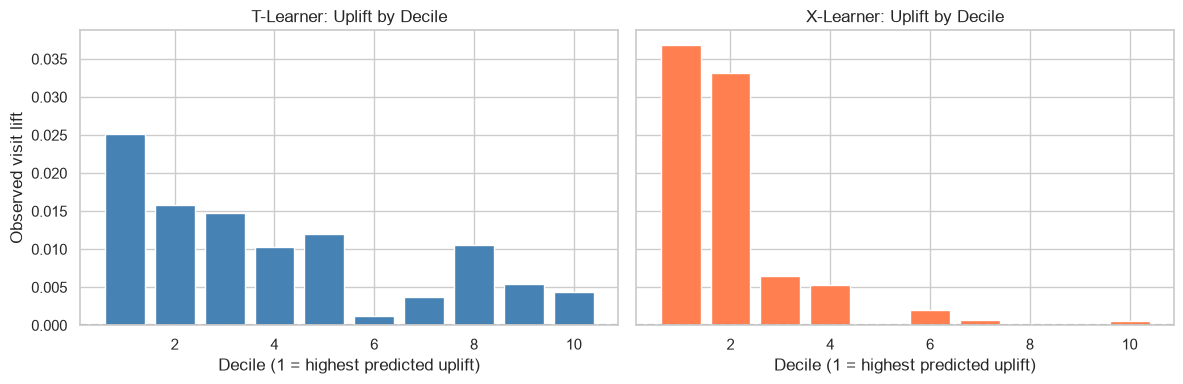

,decile,T-Learner,X-Learner
0,1,0.0252,0.0369
1,2,0.0158,0.0332
2,3,0.0148,0.0065
3,4,0.0102,0.0053
4,5,0.0120,0.0002
5,6,0.0013,0.0021
6,7,0.0038,0.0007
7,8,0.0105,0.0002
8,9,0.0054,0.0002
9,10,0.0043,0.0006


In [6]:
def uplift_by_decile(df, score_col="uplift"):
    d = df.copy()
    # rank users by predicted uplift score descending, then cut into 10 equal buckets
    d["rank"] = d[score_col].rank(ascending=False, method="first")
    d["decile"] = pd.qcut(d["rank"], q=10, labels=range(1, 11)).astype(int)
    # observed lift per bucket: actual visit rate difference between treatment and control
    grouped = (
        d.groupby("decile")
        .apply(lambda g: g.loc[g["treatment"] == 1, "y_true"].mean()
                       - g.loc[g["treatment"] == 0, "y_true"].mean())
        .reset_index(name="observed_lift")
    )
    return grouped

decile_t = uplift_by_decile(df_t)
decile_x = uplift_by_decile(df_x)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

axes[0].bar(decile_t["decile"], decile_t["observed_lift"], color="steelblue")
axes[0].axhline(0, color="gray", linestyle="--")
axes[0].set_title("T-Learner: Uplift by Decile")
axes[0].set_xlabel("Decile (1 = highest predicted uplift)")
axes[0].set_ylabel("Observed visit lift")

axes[1].bar(decile_x["decile"], decile_x["observed_lift"], color="coral")
axes[1].axhline(0, color="gray", linestyle="--")
axes[1].set_title("X-Learner: Uplift by Decile")
axes[1].set_xlabel("Decile (1 = highest predicted uplift)")

plt.tight_layout()
plt.savefig("../images/uplift_by_decile.png", dpi=150, bbox_inches="tight")
plt.show()

summary = decile_t.rename(columns={"observed_lift": "T-Learner"}).merge(
    decile_x.rename(columns={"observed_lift": "X-Learner"}), on="decile"
)
summary["T-Learner"] = summary["T-Learner"].map("{:.4f}".format)
summary["X-Learner"] = summary["X-Learner"].map("{:.4f}".format)
summary

- **X-Learner:** observed lift drops sharply after decile 2 (0.0369 → 0.0332 → near zero), meaning persuadables are tightly concentrated in the top 20% of the ranking.
- **T-Learner:** signal spreads more loosely across deciles with noisy mid-range values (e.g. decile 8 at 0.0105), reflecting weaker separation between high and low uplift users.

## 6. Summary

X-Learner outperforms T-Learner across all three evaluation lenses.

| Metric | T-Learner | X-Learner |
|---|---|---|
| Qini AUC | 0.0380 | 0.0760 |
| Incremental visits at top 20% | 984 | 1,684 (+71%) |
| Decile 1 observed lift | 0.0252 | 0.0369 |

The advantage is largest when targeting a small fraction of users, which is the realistic budget-constrained scenario. At 20% targeting, X-Learner captures 71% more incremental visits. By 80%, the gap narrows to 7%, and both models converge at 100%.

The decile chart confirms why: X-Learner pushes more of the true persuadables into the top buckets, whereas T-Learner spreads signal more loosely across the ranking. This is consistent with X-Learner being designed for imbalanced treatment/control data (85/15 here), borrowing information across groups in a way T-Learner cannot.